# UN Calibration - Clean Reference Notebook

Loads the **v14 rank-1 candidate** from the Optuna study CSV and reruns the
full M7/capture_only model with v14's **rhoSat** dislocation-density law:

$$\rho_d(F, T) = \rho_\text{scale} \cdot \rho_0(F) \cdot f_\text{sat}(T)$$

where $f_\text{sat}(T)$ is the saturating Ray–Blank fit (see Section 5 below)
and $\rho_\text{scale}$ is the single global multiplier fitted by Optuna.

**Sections**

1. Imports + load v14 rank-1 candidate
2. Equations solved (M7 / capture_only family)
3. Smoke test (matches CSV's `swD_1p3_1600K`, `Rd_1p3_1600K`, `Nd_1p3_1600K`)
4. Swelling vs T at 1.1 / 1.3 / 3.2 % FIMA (Rizk Fig. 3, three burnups, student-style labels)
5. Ray & Blank dislocation density vs T at 6.8 a/o (Blank 1984 Table 3 fit validation)
6. ρ_d(F, T) — the rhoSat law applied to the v14 candidate
7. R_d, N_d vs T at 1.3 % FIMA (Rizk Fig. 7 / 8)
8. Gas partition vs T (Rizk Fig. 9 style)
9. v14 best-candidate table


## 1. Imports and v14 candidate


In [29]:
import sys, pathlib, importlib.util
_HERE = pathlib.Path.cwd().resolve()
while _HERE.name != "un_calibration" and _HERE.parent != _HERE:
    _HERE = _HERE.parent
sys.path.insert(0, str(_HERE / "model"))
sys.path.insert(0, str(_HERE / "optuna"))

import un_data
import UN_M7_optuna_calibration_v8_core as m

v14_path = _HERE / "optuna" / "UN_M7_optuna_calibration_v14_rhoSat_qgbStrict_NdAnchors_STANDALONE.py"
spec = importlib.util.spec_from_file_location("v14_std", v14_path)
v14 = importlib.util.module_from_spec(spec)
sys.modules["v14_std"] = v14
spec.loader.exec_module(v14)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Loaded:", m.__name__, "(M7 / capture_only base) and v14 rhoFT2 wrapper")


Loaded: UN_M7_optuna_calibration_v8_core (M7 / capture_only base) and v14 rhoFT2 wrapper


In [30]:
# ============================================================================
# CANDIDATE SELECTION — toggle between CSV-loaded and hardcoded parameters
# ============================================================================
# Set USE_MANUAL_PARAMS = True to override the CSV with the values in
# MANUAL_PARAMS below (useful for plugging in a candidate from a different
# Optuna run, like a 500-trial study not synced into this repo).
USE_MANUAL_PARAMS = True

# Set USE_RAW_RHO_D = True to bypass v14's rhoFT2 wrapper entirely and use
# MANUAL_PARAMS["rho_d"] directly as a constant ρ_d in all equations.
# (This disables the saturating Ray-Blank T-shape and the burnup growth law.
#  Only meaningful in MANUAL mode; ignored when USE_MANUAL_PARAMS = False.)
USE_RAW_RHO_D = True

MANUAL_PARAMS = {
    "label": "manual_candidate",

    # --- Core physics (fitted) ---
    "f_n":          1.81e-7,    # bulk nucleation factor (Rizk default 1e-6)
    "K_d":          3.53e5,     # atoms per dislocation line length (bub/m)
    "rho_d":        3.0e13,     # baseline dislocation density (m^-2) — typically fixed
    "fission_rate": 7.03e19,    # fissions / (m^3 s)

    # --- rhoSat scale + M7 fitted scales ---
    "rho_scale":            1.635,   # multiplier on the saturating Ray-Blank shape
    "coalescence_d_scale":  1.81,
    "capture_scale":        0.065,

    # --- Trapping/resolution scales (v14 search range, but theoretical) ---
    "gb_scale":             1.0,
    "gd_bubble_scale":      1.0,
    "gd_line_scale":        1.0,
    "gd_line_alpha":        1.0,
    "b_bulk_scale":         1.0,
    "b_dislocation_scale":  1.0,

    # --- Diffusivity scales (Rizk Table 2 — typically locked at 1.0) ---
    "Dv_scale":     1.0,
    "Dv_D1_scale":  1.0,
    "Dv_D2_scale":  1.0,
    "Dg_scale":     1.0,
    "Dg_D1_scale":  1.0,
    "Dg_D3_scale":  1.0,

    # --- Aggregate / deprecated scales (locked at 1.0) ---
    "b_scale":      1.0,
    "gd_scale":     1.0,
    "D2_xe_scale":  1.0,
}

if USE_MANUAL_PARAMS:
    p = MANUAL_PARAMS
    cand = m.Candidate(
        label=p["label"], f_n=p["f_n"], K_d=p["K_d"], rho_d=p["rho_d"],
        fission_rate=p["fission_rate"],
        Dv_scale=p["Dv_scale"], Dv_D1_scale=p["Dv_D1_scale"], Dv_D2_scale=p["Dv_D2_scale"],
        Dg_scale=p["Dg_scale"], Dg_D1_scale=p["Dg_D1_scale"], Dg_D3_scale=p["Dg_D3_scale"],
        b_scale=p["b_scale"], gb_scale=p["gb_scale"], gd_scale=p["gd_scale"],
        b_bulk_scale=p["b_bulk_scale"], b_dislocation_scale=p["b_dislocation_scale"],
        gd_bubble_scale=p["gd_bubble_scale"], gd_line_scale=p["gd_line_scale"],
        gd_line_alpha=p["gd_line_alpha"],
        coalescence_d_scale=p["coalescence_d_scale"], capture_scale=p["capture_scale"],
        D2_xe_scale=p["D2_xe_scale"],
    )
    v14.RHO_SCALE_BY_LABEL[cand.label] = p["rho_scale"]
    row = {"label": p["label"], "rho_scale": p["rho_scale"], "score_total": float('nan')}
    df = None
    print(f"--- USING MANUAL PARAMETERS ---")
    print(f"  label                = {cand.label}")
    print(f"  (no fitted score — these are user-supplied values)")
else:
    csv_path = _HERE / "results" / "UN_M7_optuna_v14_rhoSat_qgbStrict_NdAnchors_results" / "capture_only" / "optuna_final_top_capture_only.csv"
    df = pd.read_csv(csv_path).sort_values('score_total').reset_index(drop=True)
    row = df.iloc[0].to_dict()
    cand = v14.candidate_from_score_row_v10c(row, label_prefix="v14_rank1")
    print(f"--- LOADED v14 rank-1 FROM CSV ---")
    print(f"  label                = {row['label']}")
    print(f"  score_total          = {row['score_total']:.3f}")

print(f"  f_n                  = {cand.f_n:.2e}")
print(f"  K_d                  = {cand.K_d:.2e}")
print(f"  rho_scale            = {row['rho_scale']:.4f}")
print(f"  fission_rate         = {cand.fission_rate:.2e}")
print(f"  scaling factors:")
print(f"    gb_scale            = {cand.gb_scale:.3f}")
print(f"    gd_bubble_scale     = {cand.gd_bubble_scale:.3f}")
print(f"    gd_line_scale       = {cand.gd_line_scale:.3f}")
print(f"    b_bulk_scale        = {cand.b_bulk_scale:.3f}")
print(f"    b_dislocation_scale = {cand.b_dislocation_scale:.3f}")
print(f"    coalescence_d_scale = {cand.coalescence_d_scale:.3f}")
print(f"    capture_scale       = {cand.capture_scale:.3f}")

# --- model_runner selection ---
# All downstream plots use model_runner(T, bu, cand, dt_h, n_modes).
# Default (rhoFT2): apply the saturating Ray-Blank rho_d law.
# USE_RAW_RHO_D=True: bypass rhoFT2; cand.rho_d is the constant ρ_d.
if USE_MANUAL_PARAMS and USE_RAW_RHO_D:
    def model_runner(T, bu, c, dt_h, n_modes):
        return m.run_model_point(T, bu, c, dt_h, n_modes)
    print(f"\n  model_runner: m.run_model_point (RAW ρ_d = {cand.rho_d:.2e} m^-2, no rhoFT2)")
else:
    def model_runner(T, bu, c, dt_h, n_modes):
        return v14.run_model_point_rhoFT2(T, bu, c, dt_h, n_modes)
    print(f"\n  model_runner: v14.run_model_point_rhoFT2 (rhoSat law, rho_scale={row['rho_scale']:.3f})")


--- USING MANUAL PARAMETERS ---
  label                = manual_candidate
  (no fitted score — these are user-supplied values)
  f_n                  = 1.81e-07
  K_d                  = 3.53e+05
  rho_scale            = 1.6350
  fission_rate         = 7.03e+19
  scaling factors:
    gb_scale            = 1.000
    gd_bubble_scale     = 1.000
    gd_line_scale       = 1.000
    b_bulk_scale        = 1.000
    b_dislocation_scale = 1.000
    coalescence_d_scale = 1.810
    capture_scale       = 0.065

  model_runner: m.run_model_point (RAW ρ_d = 3.00e+13 m^-2, no rhoFT2)


In [31]:
# Quick-look values — computed on the fly so they work for both CSV-loaded
# and manual candidates. Uses FAST settings (dt=12 h, n_modes=25) for speed.
DT_QUICK = 12.0
NM_QUICK = 25
out_1400 = model_runner(1400.0, 1.3, cand, DT_QUICK, NM_QUICK)
out_2000 = model_runner(2000.0, 1.3, cand, DT_QUICK, NM_QUICK)
out_q_1p1 = model_runner(2000.0, 1.1, cand, DT_QUICK, NM_QUICK)
out_q_3p2 = model_runner(2000.0, 3.2, cand, DT_QUICK, NM_QUICK)

rho_scale_val = v14.RHO_SCALE_BY_LABEL.get(cand.label, 1.0)
score_str = f"{row['score_total']:.4f}" if not USE_MANUAL_PARAMS else "(manual: no fitted score)"

print("=" * 60)
print(f"Quick-look values  ({'MANUAL' if USE_MANUAL_PARAMS else 'CSV'} candidate)")
print("=" * 60)
print(f"  score_final              = {score_str}")
print(f"  rho_scale                = {rho_scale_val:.4f}")
print(f"  coalescence_d_scale      = {cand.coalescence_d_scale:.4f}")
print(f"  capture_scale            = {cand.capture_scale:.4f}")
print(f"  Nd(1400 K, 1.3 % FIMA)   = {out_1400['Nd']:.3e} m^-3")
print(f"  Nd(2000 K, 1.3 % FIMA)   = {out_2000['Nd']:.3e} m^-3")
print(f"  Rd(2000 K, 1.3 % FIMA)   = {out_2000['Rd_nm']:.1f} nm")
print(f"  qgb (1.1 % FIMA, 2000 K) = {out_q_1p1['qgb_gas_percent']:.2f} %")
print(f"  qgb (3.2 % FIMA, 2000 K) = {out_q_3p2['qgb_gas_percent']:.2f} %")


Quick-look values  (MANUAL candidate)
  score_final              = (manual: no fitted score)
  rho_scale                = 1.6350
  coalescence_d_scale      = 1.8100
  capture_scale            = 0.0650
  Nd(1400 K, 1.3 % FIMA)   = 9.863e+18 m^-3
  Nd(2000 K, 1.3 % FIMA)   = 9.202e+16 m^-3
  Rd(2000 K, 1.3 % FIMA)   = 986.7 nm
  qgb (1.1 % FIMA, 2000 K) = 6.57 %
  qgb (3.2 % FIMA, 2000 K) = 6.69 %


## 2. Equations solved (M7 / capture_only family)

The model evolves three intra-granular gas reservoirs (concentration of gas in
solution $c$, in bulk bubbles $m_b$, in dislocation bubbles $m_d$) and the
bubble populations $(N_b, V_b)$ and $(N_d, V_d)$. Equations active for
**capture_only** (φ-resolution off, nucleation-mass-coupling off,
bulk→dislocation capture **on**):

### Spectral 3-equation gas balance (sphere of radius $r_g$)

$$
\frac{\partial c}{\partial t} = D_g \nabla^2 c \;-\; (g_b + g_d)\, c \;+\; b_b\, m_b \;+\; b_d\, m_d \;+\; \beta
$$

$$
\frac{dm_b}{dt} = g_b\, c - b_b\, m_b, \qquad
\frac{dm_d}{dt} = g_d\, c - b_d\, m_d
$$

with $\beta = y_{\text{Xe}}\dot{F}$ (production rate). Solved spectrally on
$N_\text{modes}$ Fourier modes with backward Euler in time.

### Resolution rates (Nelson 1969 / Rizk Eq. 8)

$$
b_b = \dot{F}\, b_0(R_b + r_l), \qquad b_d = \dot{F}\, b_0(R_d + r_l), \qquad
b_0(R) = 10^{-25}\big[\,2.64 - 2.02\,e^{-2.61\!\times\!10^{-9}/R}\,\big]
$$

### Trapping rates (Rizk Eq. 22 / 23)

$$
g_b = 4\pi D_g (R_b + r_l) N_b
$$

$$
g_d = 4\pi D_g (R_d + r_l) N_d \;+\; \frac{2\pi D_g}{\ln(\Gamma_d / Z_d r_d) - 3/5}\,(\rho_d - 2 R_d N_d)
$$

(Rizk Eq. 23 has a published typo — extra $\rho_d$ on numerator gives wrong units; corrected here.)

### Bulk nucleation (Rizk Eq. 26)

$$
\nu_b = 8\pi f_n\, D_g\, \Omega_{fg}^{1/3}\, c^2, \qquad
\frac{dN_b}{dt} = \nu_b - b_b \phi_b N_b
$$

### Bulk → dislocation capture (Barani-like, capture_only specific)

$$
f_\text{cap} = \min\!\Big(1,\ \max\big(0,\ s_\text{cap}\, N_d\, \Delta V_\text{cap}\big)\Big)
$$

### Coalescence (dislocation only — Rizk Eq. 11 / 15)

$$
N_d \leftarrow \frac{N_d}{1 + s_\text{coal,d}\, \cdot 4\,\lambda_d\, N_d\, \Delta V_{d,\text{growth}}},
\qquad
\lambda_d = \frac{2 - \xi}{2(1-\xi)^3}, \quad \xi = V_d N_d
$$

### Vacancy absorption (implicit, Rizk Eq. 21f)

$$
\frac{dn_v}{dt} = \frac{2\pi D_v\, \delta_{WS}\, N}{k_B T\, \zeta(R, N)}\,(p_\text{int} - p_\text{eq}),\qquad
p_\text{int} = \frac{k_B T\, m_\text{gas}}{n_v\, \Omega},\qquad
p_\text{eq} = \frac{2\gamma}{R} - \sigma_h
$$

### Volume / radius update

$$
V = \frac{\Omega_{fg}\, m_\text{gas} + \Omega\, n_v}{N},\qquad R = (3V/4\pi)^{1/3}
$$

### Dislocation density (rhoSat law, Rizk + Ray–Blank)

$$
\rho_d(F, T) = \rho_\text{scale} \cdot \rho_0(F) \cdot f_\text{sat}(T),\qquad
\rho_0(F) = \max(\rho_\text{FAB},\, C_1(F-F_0))
$$

with $C_1 = 1.6\!\times\!10^{14}$ m⁻²/(a/o), $F_0 = 2.4$ a/o, $\rho_\text{FAB} = 3\!\times\!10^{13}$ m⁻² (Blank 1984).


## 3. Smoke test (must match the CSV's `swD_1p3_1600K`, `Rd_1p3_1600K`, `Nd_1p3_1600K`)


In [32]:
DT_H = 12.0
N_MODES = 25

out = model_runner(1600.0, 1.3, cand, DT_H, N_MODES)

print(f"Single-point run via v14 rhoFT2 wrapper at T=1600 K, 1.3 % FIMA:\n")
if USE_MANUAL_PARAMS:
    print(f"  {'quantity':<26s} {'model':>12s}")
    print(f"  {'swelling (dislocation)':<26s} {out['swelling_d_percent']:>11.3f} %")
    print(f"  {'R_d':<26s} {out['Rd_nm']:>10.1f} nm")
    print(f"  {'N_d':<26s} {out['Nd']:>12.2e}")
else:
    print(f"  {'quantity':<26s} {'model':>12s}    {'CSV target':>12s}")
    print(f"  {'swelling (dislocation)':<26s} {out['swelling_d_percent']:>11.3f} %  {row['swD_1p3_1600K']:>11.3f} %")
    print(f"  {'R_d':<26s} {out['Rd_nm']:>10.1f} nm  {row['Rd_1p3_1600K']:>10.1f} nm")
    print(f"  {'N_d':<26s} {out['Nd']:>12.2e}    {row['Nd_1p3_1600K']:>12.2e}")
print()
print(f"  swelling (bulk)        = {out['swelling_b_percent']:.3f} %")
print(f"  R_b                    = {out['Rb_nm']:.1f} nm")
print(f"  Gas partition: matrix={out['matrix_gas_percent']:.1f}%  bulk={out['bulk_gas_percent']:.1f}%  "
      f"disl={out['dislocation_gas_percent']:.1f}%  q_gb={out['qgb_gas_percent']:.1f}%")


Single-point run via v14 rhoFT2 wrapper at T=1600 K, 1.3 % FIMA:

  quantity                          model
  swelling (dislocation)           4.014 %
  R_d                             107.1 nm
  N_d                            7.80e+18

  swelling (bulk)        = 1.145 %
  R_b                    = 17.1 nm
  Gas partition: matrix=0.2%  bulk=42.1%  disl=52.5%  q_gb=5.2%


## 4. Swelling vs T at 1.1 / 1.3 / 3.2 % FIMA — student-style

Three side-by-side panels, one per burnup. Model curves labelled
`M7 dislocation/P2 swelling` and `M7 bulk swelling`; experimental data
(Rizk Fig. 3) plotted as black markers. The 1.1 % FIMA panel splits
the experimental data by linear power (100 kW/m vs 119 kW/m); the
1.3 % and 3.2 % panels show the single available measurement series.
Uses the v14 rank-1 candidate (loaded in section 1).


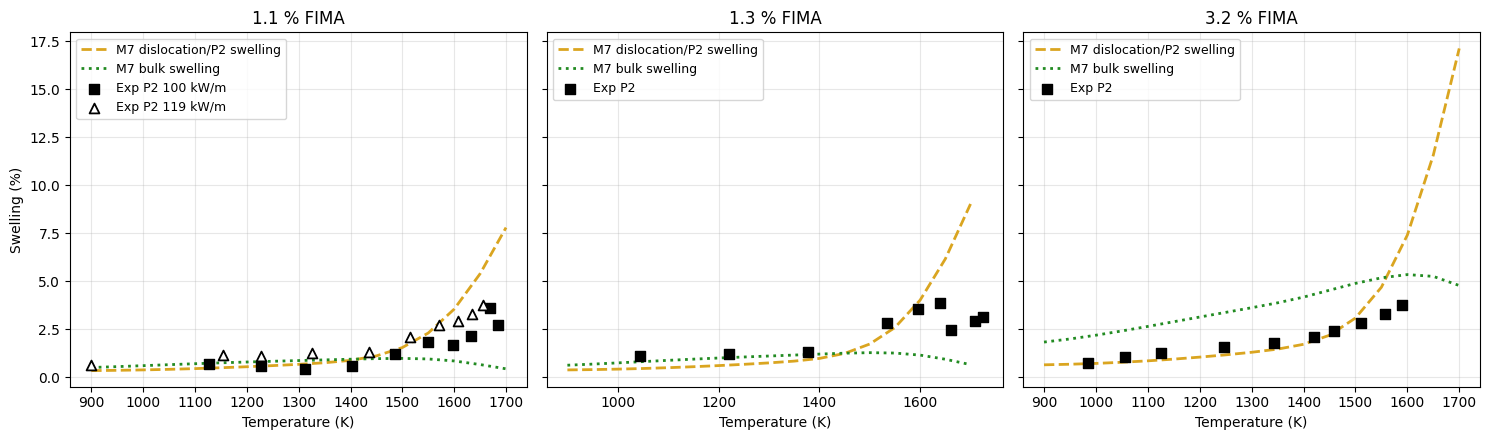

In [33]:
T_grid = np.arange(900, 1750, 50)
burnups = [1.1, 1.3, 3.2]
points = [(float(T), bu) for bu in burnups for T in T_grid]

results = [model_runner(T, bu, cand, DT_H, N_MODES) for (T, bu) in points]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, bu in zip(axes, burnups):
    rs = [r for r in results if abs(r['burnup'] - bu) < 0.01]
    Ts = [r['T'] for r in rs]
    swD = [r['swelling_d_percent'] for r in rs]
    swB = [r['swelling_b_percent'] for r in rs]
    ax.plot(Ts, swD, '--', linewidth=2, color='goldenrod', label='M7 dislocation/P2 swelling')
    ax.plot(Ts, swB, ':',  linewidth=2, color='forestgreen', label='M7 bulk swelling')

    if abs(bu - 1.1) < 0.01:
        # Two power series for 1.1 % FIMA
        exp_100 = [p for p in un_data.EXP_SWELLING_T if abs(p['burnup'] - 1.1) < 0.01 and p['series'] == '100 kW/m']
        exp_119 = [p for p in un_data.EXP_SWELLING_T if abs(p['burnup'] - 1.1) < 0.01 and p['series'] == '119 kW/m']
        ax.scatter([p['T'] for p in exp_100], [p['swelling'] for p in exp_100],
                   marker='s', s=50, color='black', label='Exp P2 100 kW/m', zorder=5)
        ax.scatter([p['T'] for p in exp_119], [p['swelling'] for p in exp_119],
                   marker='^', s=50, facecolor='white', edgecolor='black',
                   linewidth=1.3, label='Exp P2 119 kW/m', zorder=5)
    else:
        exp = [p for p in un_data.EXP_SWELLING_T if abs(p['burnup'] - bu) < 0.01]
        ax.scatter([p['T'] for p in exp], [p['swelling'] for p in exp],
                   marker='s', s=50, color='black', label='Exp P2', zorder=5)

    ax.set_xlabel('Temperature (K)')
    ax.set_title(f'{bu} % FIMA')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')
axes[0].set_ylabel('Swelling (%)')
plt.tight_layout()
plt.show()


## 5. Ray & Blank dislocation density vs T at 6.8 a/o

Validates the saturating temperature shape used by v14 against the original
Blank 1984 Table 3 measurements (specimen C3/1 at 6.8 a/o burnup, sodium-bonded
carbide). The five experimental points come directly from that table; the
solid line is the v14 module's `rho_sat_shape10(T)`:

$$\rho_d(T) = \rho_\infty - (\rho_\infty - \rho_{940})\,\exp\!\left(-\frac{T - 940}{\tau}\right)$$

with $\rho_{940} = 6.357$, $\rho_\infty = 9.104$, $\tau = 203.76$ K (units of
$10^{10}$ cm/cm³, equivalent to $10^{14}$ m⁻²).

This is the shape that gets multiplied by the Ray–Blank burnup law and the
fitted `rho_scale` to give the effective $\rho_d(F, T)$ in section 6.


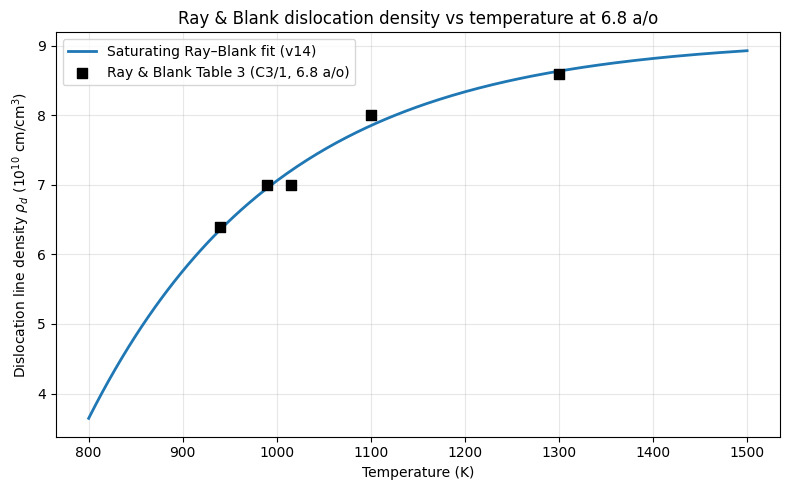

In [34]:
T_grid = np.linspace(800, 1500, 200)
rho_curve = np.array([v14.rho_sat_shape10(T) for T in T_grid])

# Blank 1984 Table 3, specimen C3/1 at 6.8 a/o burnup (sodium-bonded carbide)
rb_T   = [940.0, 990.0, 1015.0, 1100.0, 1300.0]
rb_rho = [6.4,   7.0,   7.0,    8.0,    8.6]   # units: 10^10 cm/cm^3 = 10^14 m^-2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T_grid, rho_curve, '-', linewidth=2, color='tab:blue',
        label='Saturating Ray–Blank fit (v14)')
ax.scatter(rb_T, rb_rho, marker='s', s=60, color='black',
           label='Ray & Blank Table 3 (C3/1, 6.8 a/o)', zorder=5)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'Dislocation line density $\rho_d$ ($10^{10}$ cm/cm$^3$)')
ax.set_title('Ray & Blank dislocation density vs temperature at 6.8 a/o')
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 6. ρ_d(F, T) — the rhoSat dislocation-density law

In v14, the dislocation density follows a saturating Ray–Blank shape in
temperature, multiplied by a Ray–Blank burnup law and a single global `rho_scale`:

$$\rho_d(F, T) = \rho_\text{scale} \cdot \rho_0(F) \cdot f_\text{sat}(T)$$

- $\rho_0(F) = \max(\rho_\text{FAB},\, C_1 \cdot (F - F_0))$ — Ray–Blank burnup growth
- $f_\text{sat}(T) = \rho_\infty - (\rho_\infty - \rho_{940})\,\exp\!\left(-\frac{T - 940}{\tau}\right)$, normalised at 1025 K
- v14 fits only $\rho_\text{scale}$ in $[0.5, 2.0]$ — for the rank-1 candidate
  this came out near **0.58**.

The plot below shows the effective $\rho_d(F, T)$ at three burnups for the rank-1 candidate.


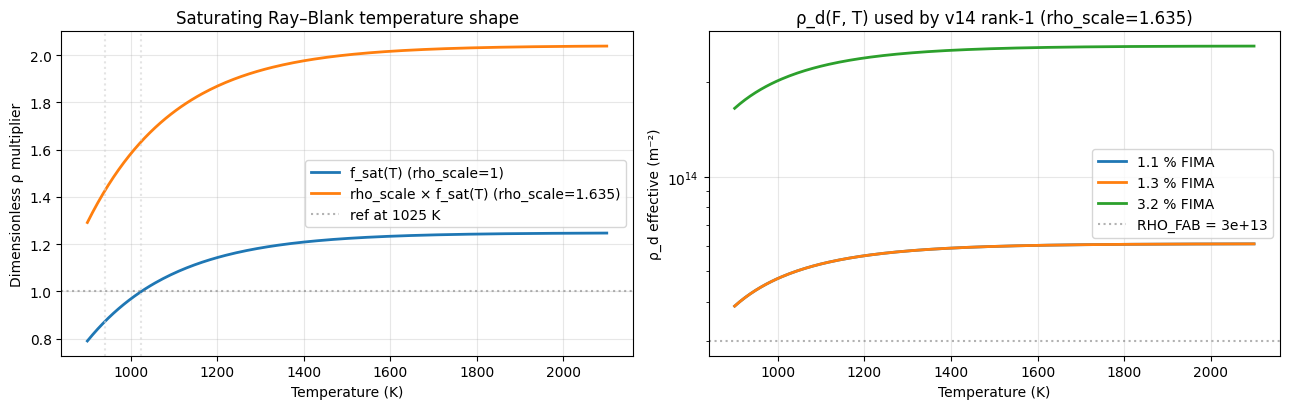

ρ_d effective at the v14 rank-1 candidate (m⁻²):
   T (K)       1.1 %       1.3 %       3.2 %
     900    3.87e+13    3.87e+13    1.65e+14
    1300    5.81e+13    5.81e+13    2.48e+14
    1600    6.05e+13    6.05e+13    2.58e+14
    1800    6.09e+13    6.09e+13    2.60e+14
    2000    6.11e+13    6.11e+13    2.61e+14


In [35]:
T_grid = np.linspace(900, 2100, 200)
burnups_plot = [1.1, 1.3, 3.2]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

fsat = np.array([v14.rho_sat_factor_raw(T) for T in T_grid])
fsat_scaled = row['rho_scale'] * fsat
axes[0].plot(T_grid, fsat, '-', linewidth=2, label=f'f_sat(T) (rho_scale=1)')
axes[0].plot(T_grid, fsat_scaled, '-', linewidth=2,
             label=f'rho_scale × f_sat(T) (rho_scale={row["rho_scale"]:.3f})')
axes[0].axhline(1.0, color='gray', linestyle=':', alpha=0.6, label='ref at 1025 K')
axes[0].axvline(940, color='lightgray', linestyle=':', alpha=0.6)
axes[0].axvline(1025, color='lightgray', linestyle=':', alpha=0.6)
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel('Dimensionless ρ multiplier')
axes[0].set_title('Saturating Ray–Blank temperature shape')
axes[0].legend()
axes[0].grid(alpha=0.3)

for bu in burnups_plot:
    rho_eff = np.array([v14.rho_ray_blank_eff_FT2(T, bu, cand) for T in T_grid])
    axes[1].plot(T_grid, rho_eff, linewidth=2, label=f'{bu} % FIMA')
axes[1].axhline(v14.RHO_FAB, color='gray', linestyle=':', alpha=0.6, label=f'RHO_FAB = {v14.RHO_FAB:.0e}')
axes[1].set_xlabel('Temperature (K)')
axes[1].set_ylabel('ρ_d effective (m⁻²)')
axes[1].set_title(f'ρ_d(F, T) used by v14 rank-1 (rho_scale={row["rho_scale"]:.3f})')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print("ρ_d effective at the v14 rank-1 candidate (m⁻²):")
print(f"  {'T (K)':>6s}  {'1.1 %':>10s}  {'1.3 %':>10s}  {'3.2 %':>10s}")
for T in [900, 1300, 1600, 1800, 2000]:
    cells = [v14.rho_ray_blank_eff_FT2(T, bu, cand) for bu in burnups_plot]
    print(f"  {T:>6d}  {cells[0]:>10.2e}  {cells[1]:>10.2e}  {cells[2]:>10.2e}")


## 7. Dislocation-bubble radius and concentration vs T at 1.3 % FIMA (Rizk Fig. 7 / 8)

With the v14 calibration **R_d matches the experimental anchors well** (this
is what the Fig.8 anchor terms in the score were designed to do).
**N_d does not match low-T experimental densities** — the model is too flat.

**Why N_d misses the low-T high-density region**:

The model's initial $N_d = K_d \cdot \rho_d^{\text{eff}}(T)$ and can only
**decrease** afterwards via coalescence. For the v14 rank-1 candidate:

- $K_d = 3.5\times 10^5$ — Optuna pinned this at the **lower bound** of its search range $[3\times 10^5,\, 8\times 10^5]$
- $\rho_d^{\text{eff}}(900\text{ K}) \approx 1.4\times 10^{13}$ m⁻²
- ⇒ Initial $N_d \approx 4.9\times 10^{18}$ m⁻³, while Rizk reports $\sim 5\times 10^{19}$ at 1153 K

So the model is structurally **~10× below** Rizk's high-density region.
The fit chose this configuration because lowering $\rho_d^{\text{eff}}$ helped match
the partition + R_d targets — and v14's score uses **upper-bound caps** at high T
rather than absolute fits, so a flat-ish $N_d$ that stays under the caps incurs no penalty.

This is the trade-off the student documented in `un_calibration/reports/UN_M7_calibration_lessons_report.md`
§9. See also the parameter audit in `un_calibration/reports/parameter_audit.md` for
literature-anchored search-range recommendations (Blank 1984 measured K up to 1.9·10⁷,
well above v14's range).


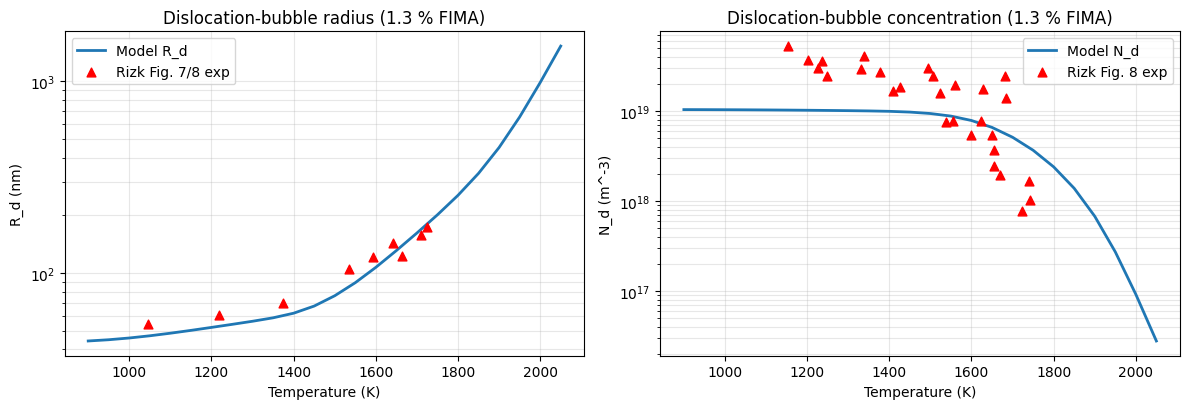

In [36]:
T_grid = np.arange(900, 2100, 50)
results = [model_runner(float(T), 1.3, cand, DT_H, N_MODES) for T in T_grid]
Ts = [r['T'] for r in results]
Rds = [r['Rd_nm'] for r in results]
Nds = [r['Nd'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(Ts, Rds, '-', linewidth=2, label='Model R_d')
ax1.scatter([p['T'] for p in un_data.EXP_RD_T_13], [p['R_nm'] for p in un_data.EXP_RD_T_13],
            color='red', s=40, marker='^', label='Rizk Fig. 7/8 exp', zorder=5)
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('R_d (nm)')
ax1.set_yscale('log')
ax1.set_title('Dislocation-bubble radius (1.3 % FIMA)')
ax1.legend()
ax1.grid(alpha=0.3, which='both')

ax2.semilogy(Ts, Nds, '-', linewidth=2, label='Model N_d')
ax2.scatter([p['T'] for p in un_data.EXP_ND_T_13], [p['N'] for p in un_data.EXP_ND_T_13],
            color='red', s=40, marker='^', label='Rizk Fig. 8 exp', zorder=5)
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('N_d (m^-3)')
ax2.set_title('Dislocation-bubble concentration (1.3 % FIMA)')
ax2.legend()
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()


## 8. Gas partition vs T at 1.3 % FIMA (Rizk Fig. 9 style)


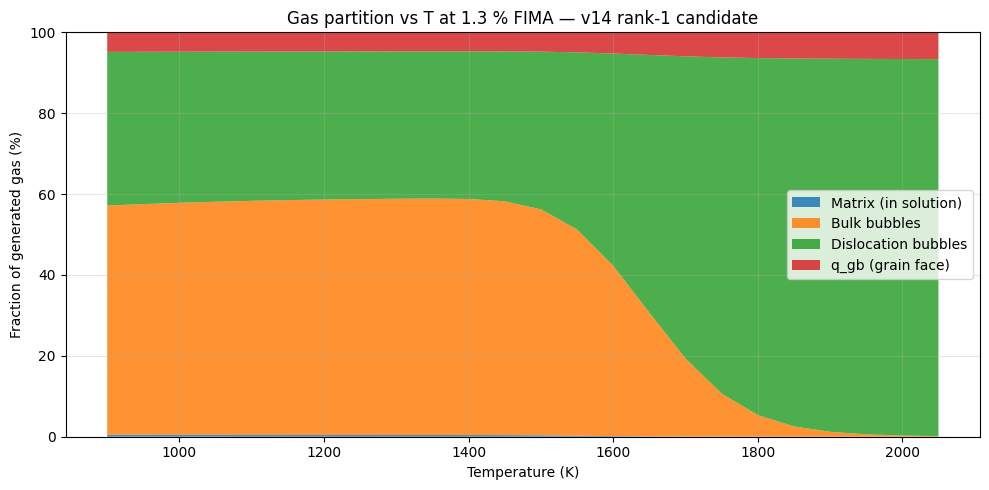

In [37]:
T_grid = np.arange(900, 2100, 50)
results = [model_runner(float(T), 1.3, cand, DT_H, N_MODES) for T in T_grid]
Ts = [r['T'] for r in results]
matrix = [r['matrix_gas_percent'] for r in results]
bulk = [r['bulk_gas_percent'] for r in results]
disl = [r['dislocation_gas_percent'] for r in results]
qgb = [r['qgb_gas_percent'] for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(Ts, matrix, bulk, disl, qgb,
             labels=['Matrix (in solution)', 'Bulk bubbles',
                     'Dislocation bubbles', 'q_gb (grain face)'],
             alpha=0.85)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Fraction of generated gas (%)')
ax.set_title('Gas partition vs T at 1.3 % FIMA — v14 rank-1 candidate')
ax.set_ylim(0, 100)
ax.legend(loc='center right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. v14 best-candidate table


In [38]:
if df is None:
    print("Manual-parameter mode: no CSV table to display.")
    print("Set USE_MANUAL_PARAMS = False in section 1 to load v14 candidates from CSV.")
else:
    cols = [c for c in [
        'label', 'score_total', 'f_n', 'K_d', 'rho_d', 'rho_scale', 'fission_rate',
        'gb_scale', 'gd_bubble_scale', 'gd_line_scale',
        'b_bulk_scale', 'b_dislocation_scale',
        'coalescence_d_scale', 'capture_scale',
        'swD_1p3_1600K', 'Rd_1p3_1600K', 'Nd_1p3_1600K',
    ] if c in df.columns]
    pd.set_option('display.float_format', '{:.3g}'.format)
    print(f"Top {min(5, len(df))} v14 candidates (sorted by score_total ascending):\n")
    print(df[cols].head(5).to_string(index=False))


Manual-parameter mode: no CSV table to display.
Set USE_MANUAL_PARAMS = False in section 1 to load v14 candidates from CSV.


---

End of clean notebook. To rerun cells: Kernel → Restart & Run All.
